# Airbnb in Asheville
Monica Reyes-Lopez\
DSBA 6211 Advanced Business Analytics\
Spring 2026

Data Dictionary
https://docs.google.com/spreadsheets/d/1iWCNJcSutYqpULSQHlNyGInUvHg2BoUGoNRIGa6Szc4/edit?gid=1322284596#gid=1322284596


## Leading questions:
- what factors affect air bnbs listings' performance?
- propose reasonable indicators to quantify an individual listings' performance
    - avg monthly occupancy rate, or avg monthly income per room
- identify suitable independent variables based on available data sources

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import json
import plotly.express as px
import numpy as np


In [4]:
# bringing in the most recent data 
calendar_recent = pd.read_csv(r'data\now\calendar.csv.gz', compression='gzip')
listings_recent = pd.read_csv(r'data\now\listings.csv.gz', compression='gzip')
reviews_recent = pd.read_csv(r'data\now\reviews.csv.gz', compression='gzip')
neighborhoods_recent = pd.read_csv(r'data\now\neighbourhoods.csv')
neighborhoods_geo = json.load(open(r'data\now\neighbourhoods.geojson', 'r'))
    # neighborhoods_geo is the same in both the archived and recent data, so we only need to load it once
    
# summary data
listing_summary_recent = pd.read_csv(r'data\now\summary\listings.csv')
reviews_summary_recent = pd.read_csv(r'data\now\summary\reviews.csv')
# -----------------------------------------------------------------------------------

# archived data
calendar_archived = pd.read_csv(r'data\archived\calendar.csv.gz', compression='gzip')
listings_archived = pd.read_csv(r'data\archived\listings.csv.gz', compression='gzip')
reviews_archived = pd.read_csv(r'data\archived\reviews.csv.gz', compression='gzip')
neighborhoods_archived = pd.read_csv(r'data\archived\neighbourhoods.csv')
# neighborhoods_geo_archived = json.load(open(r'data\archived\neighbourhoods.geojson', 'r'))

# summary data
listing_summary_archived = pd.read_csv(r'data\archived\summary\listings.csv')
reviews_summary_archived = pd.read_csv(r'data\archived\summary\reviews.csv')

# -----------------------------------------------------------------------------------

# making master df for each dataset
calendar = pd.concat([calendar_recent, calendar_archived], ignore_index=True)
listings = pd.concat([listings_recent, listings_archived], ignore_index=True)
reviews = pd.concat([reviews_recent, reviews_archived], ignore_index=True)
neighborhoods = neighborhoods_recent.copy()
# neighborhoods_geo and neighborhoods do not need to be concatenated as the data is the same in both files, so we can just use one of them
# summary data
listing_summary = pd.concat([listing_summary_recent, listing_summary_archived], ignore_index=True)
reviews_summary = pd.concat([reviews_summary_recent, reviews_summary_archived], ignore_index=True)


In [5]:
## what is the shape of each dataset?
print("Calendar dataset shape:", calendar_recent.shape)
print("Listings dataset shape:", listings_recent.shape)
print("Reviews dataset shape:", reviews_recent.shape)
print("Neighborhoods dataset shape:", neighborhoods_recent.shape)
print("Neighborhoods GeoJSON keys:", neighborhoods_geo.keys())



Calendar dataset shape: (1040980, 7)
Listings dataset shape: (2852, 79)
Reviews dataset shape: (324317, 6)
Neighborhoods dataset shape: (8, 2)
Neighborhoods GeoJSON keys: dict_keys(['type', 'features'])


# Exploring the Data


We have the following datasets:


- Listings 
  - 5,728 listings, 76 features
  - including hosts from airbnb's founding date in 2008


- Calendar 
  - 1,041,345 calendar records, 5 features


- Neighborhoods 
  - 8 neighborhoods (North, South, East, West, Arden, Candler, Fletcher, Downtown/Central) 


- Reviews 
  - 642,866 reviews , 6 features
  - Both recent and archived data was taken into account, with reviews ranging from July 2011 to September 2025

In [45]:
print('Reviews date')
print(reviews['date'].describe())
print('================================')



Reviews date
count                        642866
mean     2021-12-06 23:25:05.808052
min             2011-07-31 00:00:00
25%             2020-06-07 00:00:00
50%             2022-05-02 00:00:00
75%             2023-10-25 00:00:00
max             2025-09-21 00:00:00
Name: date, dtype: object


In [46]:
cols= ['first_review', 'last_review', 'calendar_last_scraped', 'host_since', 'last_scraped']
for col in cols:
    print('column:', col)
    print(listings[col].describe())
    print('================================')

column: first_review
count                          5222
mean     2021-04-20 05:32:00.643431
min             2011-07-31 00:00:00
25%             2019-05-07 06:00:00
50%             2021-10-10 00:00:00
75%             2023-08-01 00:00:00
max             2025-09-20 00:00:00
Name: first_review, dtype: object
column: last_review
count                          5222
mean     2025-02-21 06:36:15.718115
min             2015-10-03 00:00:00
25%             2025-01-01 00:00:00
50%             2025-06-02 00:00:00
75%             2025-08-24 00:00:00
max             2025-09-21 00:00:00
Name: last_review, dtype: object
column: calendar_last_scraped
count                          5728
mean     2025-08-04 07:09:53.296089
min             2025-06-17 00:00:00
25%             2025-06-17 00:00:00
50%             2025-06-17 00:00:00
75%             2025-09-22 00:00:00
max             2025-09-22 00:00:00
Name: calendar_last_scraped, dtype: object
column: host_since
count                          5725
mean    

In [6]:
calendar.info()

<class 'pandas.DataFrame'>
RangeIndex: 1041345 entries, 0 to 1041344
Data columns (total 7 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   listing_id      1041345 non-null  int64  
 1   date            1041345 non-null  str    
 2   available       1041345 non-null  str    
 3   price           0 non-null        float64
 4   adjusted_price  0 non-null        float64
 5   minimum_nights  1041345 non-null  int64  
 6   maximum_nights  1041345 non-null  int64  
dtypes: float64(2), int64(3), str(2)
memory usage: 55.6 MB


In [7]:
#calendar cleaning
#1040980 in recent; 365 in archived; 1041345 total


# drop adjusted price column since it has 100% null values
if 'adjusted_price' in calendar.columns:
    calendar['adjusted_price'].isnull().sum()/len(calendar)
    calendar.drop(columns=['adjusted_price'], inplace=True)

#drop price column since it has 100% null values
if 'price' in calendar.columns:
    calendar['price'].isnull().sum()/len(calendar)
    calendar.drop(columns=['price'], inplace=True)

# date to datetime
calendar['date'] = pd.to_datetime(calendar['date'])

# binary values in available column are currently 't' and 'f', so we will replace them with 1 and 0
calendar['available'] = calendar['available'].replace({'t': 1, 'f': 0})

#turning available into int
calendar['available'] = calendar['available'].astype(int)

calendar.info()
calendar.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1041345 entries, 0 to 1041344
Data columns (total 5 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   listing_id      1041345 non-null  int64         
 1   date            1041345 non-null  datetime64[us]
 2   available       1041345 non-null  int64         
 3   minimum_nights  1041345 non-null  int64         
 4   maximum_nights  1041345 non-null  int64         
dtypes: datetime64[us](1), int64(4)
memory usage: 39.7 MB


,listing_id,date,available,minimum_nights,maximum_nights
count,1.041345e+06,1041345,1.041345e+06,1.041345e+06,1.041345e+06
mean,4.969128e+17,2026-03-22 23:16:05.299684,6.135411e-01,6.592270e+00,6.405132e+02
min,1.553050e+05,2025-06-27 00:00:00,0.000000e+00,1.000000e+00,1.000000e+00
25%,3.352277e+07,2025-12-22 00:00:00,0.000000e+00,2.000000e+00,1.800000e+02
50%,5.357007e+07,2026-03-23 00:00:00,1.000000e+00,2.000000e+00,3.650000e+02
75%,1.000762e+18,2026-06-22 00:00:00,1.000000e+00,3.000000e+00,1.125000e+03
max,1.513870e+18,2026-09-21 00:00:00,1.000000e+00,7.300000e+02,1.125000e+03
std,5.461964e+17,NaN,4.869380e-01,2.035107e+01,4.705566e+02


In [8]:
# listing cleaning
# each of these had all null values, so we can drop them

if 'license' in listings.columns:
    listings['license'].isnull().sum()/len(listings)
    listings.drop(columns=['license'], inplace=True)


if 'calendar_updated' in listings.columns:
    listings['calendar_updated'].isnull().sum()/len(listings)
    listings.drop(columns=['calendar_updated'], inplace=True)



if 'neighbourhood_group_cleansed' in listings.columns:
    listings['neighbourhood_group_cleansed'].isnull().sum()/len(listings)
    listings.drop(columns=['neighbourhood_group_cleansed'], inplace=True)

#dropping has_availability column since it has 100% 't' values
if 'has_availability' in listings.columns:
    listings['has_availability'].value_counts(normalize=True)
    listings.drop(columns=['has_availability'], inplace=True)



# listings_recent.shape # 2852 in recent; 
# listings_archived.shape # 2876 in archived;
# listings.shape # 5728 total
# listings.shape
listings.info()
# putting the column names in a list to make it easier to check for null values


<class 'pandas.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 75 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            5728 non-null   int64  
 1   listing_url                                   5728 non-null   str    
 2   scrape_id                                     5728 non-null   int64  
 3   last_scraped                                  5728 non-null   str    
 4   source                                        5728 non-null   str    
 5   name                                          5728 non-null   str    
 6   description                                   5630 non-null   str    
 7   neighborhood_overview                         3796 non-null   str    
 8   picture_url                                   5728 non-null   str    
 9   host_id                                       5728 non-null   int64  
 10 

In [9]:
listings_columns = listings.columns.tolist() 
listings_columns

for col in ['price', 'host_response_rate', 'host_acceptance_rate']:
    if col in listings.columns and listings[col].dtype == 'str':
        listings[col] = listings[col].str.replace('$', '').str.replace(',', '').str.replace('%', '').astype(float)

for col in ['host_since', 'first_review', 'last_review', 'last_scraped', 'calendar_last_scraped']:
        listings[col] = pd.to_datetime(listings[col])
    

# for col in ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 
#                'instant_bookable']:
#         listings[col] = listings[col].replace({'t': True, 'f': False})

listings.info()



<class 'pandas.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 75 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   id                                            5728 non-null   int64         
 1   listing_url                                   5728 non-null   str           
 2   scrape_id                                     5728 non-null   int64         
 3   last_scraped                                  5728 non-null   datetime64[us]
 4   source                                        5728 non-null   str           
 5   name                                          5728 non-null   str           
 6   description                                   5630 non-null   str           
 7   neighborhood_overview                         3796 non-null   str           
 8   picture_url                                   5728 non-null   str           
 9

In [10]:
# sorting columns in listings by the number of rull values in each column, from most to least
listings.isnull().sum().sort_values(ascending=False)

# putting these in a list where values are >0 
listings_nulls = listings.isnull().sum().sort_values(ascending=False)
listings_nulls = listings_nulls[listings_nulls > 500]
listings_nulls

host_neighbourhood             3541
host_about                     2025
neighborhood_overview          1932
neighbourhood                  1932
host_location                   903
host_response_rate              807
host_response_time              807
price                           655
beds                            655
estimated_revenue_l365d         655
bathrooms                       637
review_scores_accuracy          506
review_scores_location          506
last_review                     506
first_review                    506
review_scores_checkin           506
review_scores_cleanliness       506
review_scores_communication     506
review_scores_rating            506
reviews_per_month               506
review_scores_value             506
dtype: int64

In [11]:
listings['beds'].describe()

count    5073.000000
mean        2.794599
std         2.440619
min         0.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        50.000000
Name: beds, dtype: float64

In [12]:
# showing the listing with the max beds 
listings[listings['beds'] == listings['beds'].max()]

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
2594,1339091513653409760,https://www.airbnb.com/rooms/1339091513653409760,20250922033920,2025-09-22,city scrape,Asheville River Cabins,Imagine your family reunion or group retreat s...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,477251437,...,NaN,NaN,NaN,NaN,f,8,8,0,0,NaN
5553,1339091513653409760,https://www.airbnb.com/rooms/1339091513653409760,20250617145515,2025-06-17,city scrape,Asheville River Cabins,Imagine your family reunion or group retreat s...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,477251437,...,NaN,NaN,NaN,NaN,f,8,8,0,0,NaN


In [13]:
# reviews 
# reviews_recent.info() #324317 in recent; 318548 in archived
# reviews_archived.info() #318548 in archived
reviews.info() #642865 total
reviews['date'] = pd.to_datetime(reviews['date'])

<class 'pandas.DataFrame'>
RangeIndex: 642866 entries, 0 to 642865
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   listing_id     642866 non-null  int64
 1   id             642866 non-null  int64
 2   date           642866 non-null  str  
 3   reviewer_id    642866 non-null  int64
 4   reviewer_name  642866 non-null  str  
 5   comments       642758 non-null  str  
dtypes: int64(3), str(3)
memory usage: 29.4 MB


In [14]:
# neighborhood cleaning
if 'neighbourhood_group' in neighborhoods.columns:
    neighborhoods['neighbourhood_group'].isnull().sum()/len(neighborhoods)
    neighborhoods.drop(columns=['neighbourhood_group'], inplace=True)

# add column to include neighborhood names

zip_to_name = {
    28704: 'Arden',
    28715: 'Candler',
    28732: 'Fletcher',
    28801: 'Asheville - Downtown/Central',
    28803: 'Asheville - South',
    28804: 'Asheville - North',
    28805: 'Asheville - East',
    28806: 'Asheville - West'
}

#creating new neighbourhood_name column by mapping the neighbourhood column to the zip_to_name dictionary
neighborhoods['neighbourhood_name'] = neighborhoods['neighbourhood'].astype(int).map(zip_to_name)
# neighborhoods

neighborhoods.info()


<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   neighbourhood       8 non-null      int64
 1   neighbourhood_name  8 non-null      str  
dtypes: int64(1), str(1)
memory usage: 260.0 bytes


In [15]:
master_df = pd.concat([listings, reviews, neighborhoods, calendar], axis=1)

master_df.shape

(1041345, 88)

In [16]:
master_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1041345 entries, 0 to 1041344
Data columns (total 88 columns):
 #   Column                                        Non-Null Count    Dtype         
---  ------                                        --------------    -----         
 0   id                                            5728 non-null     float64       
 1   listing_url                                   5728 non-null     str           
 2   scrape_id                                     5728 non-null     float64       
 3   last_scraped                                  5728 non-null     datetime64[us]
 4   source                                        5728 non-null     str           
 5   name                                          5728 non-null     str           
 6   description                                   5630 non-null     str           
 7   neighborhood_overview                         3796 non-null     str           
 8   picture_url                                   5728 no

# Market Supply
The host's side of the market

(ex: number of active listings per quarter/month)

Questions: 
- How many listings exist? Are more being added over time?
- What types of properties are listed (entire home, private room, etc.)?
- How many nights are hosts making available on their calendar?
- Which neighborhoods have the most listings?



In [20]:
# Which neighborhood has the most listings?

# Count listings per neighborhood and calculate metrics
listings_per_neighborhood = listings.groupby('neighbourhood_cleansed').agg(
    num_listings=('id', 'size'),
    avg_price=('price', 'mean'),
    avg_reviews=('number_of_reviews', 'mean'),
    avg_rating=('review_scores_rating', 'mean')
).reset_index().round(2)

# Create a dict for quick lookup
metrics_dict = listings_per_neighborhood.set_index('neighbourhood_cleansed').to_dict('index')

# Add metrics to geojson properties
for feature in neighborhoods_geo['features']:
    neigh = feature['properties']['neighbourhood']
    try:
        metrics_key = int(neigh)
    except (ValueError, TypeError):
        metrics_key = neigh

    if metrics_key in metrics_dict:
        feature['properties'].update(metrics_dict[metrics_key])
    else:
        feature['properties'].update({'num_listings': 0, 'avg_price': 0, 'avg_reviews': 0, 'avg_rating': 0})

    feature['properties']['neighbourhood_name'] = zip_to_name.get(metrics_key, neigh)

# Create a folium map centered on Asheville
m = folium.Map(location=[35.5951, -82.5515], zoom_start=11)

# Add choropleth layer
folium.Choropleth(
    geo_data=neighborhoods_geo,
    data=listings_per_neighborhood,
    columns=['neighbourhood_cleansed', 'num_listings'],
    key_on='feature.properties.neighbourhood',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Number of Listings'
).add_to(m)

# Add tooltips with metrics
folium.GeoJson(
    neighborhoods_geo,
    style_function=lambda x: {'fillColor': 'transparent', 'color': 'black', 'weight': 1},
    tooltip=folium.GeoJsonTooltip(
        fields=['neighbourhood_name', 'num_listings', 'avg_price', 'avg_reviews', 'avg_rating'],
        aliases=['Neighborhood:', 'Number of Listings:', 'Avg Price ($):', 'Avg Reviews:', 'Avg Rating:'],
        localize=True
    )
).add_to(m)

# Display the map
m

C:\Users\reyes\AppData\Local\Temp\ipykernel_29520\2117272926.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, y='neighborhood_name', x='num_listings', palette='viridis')


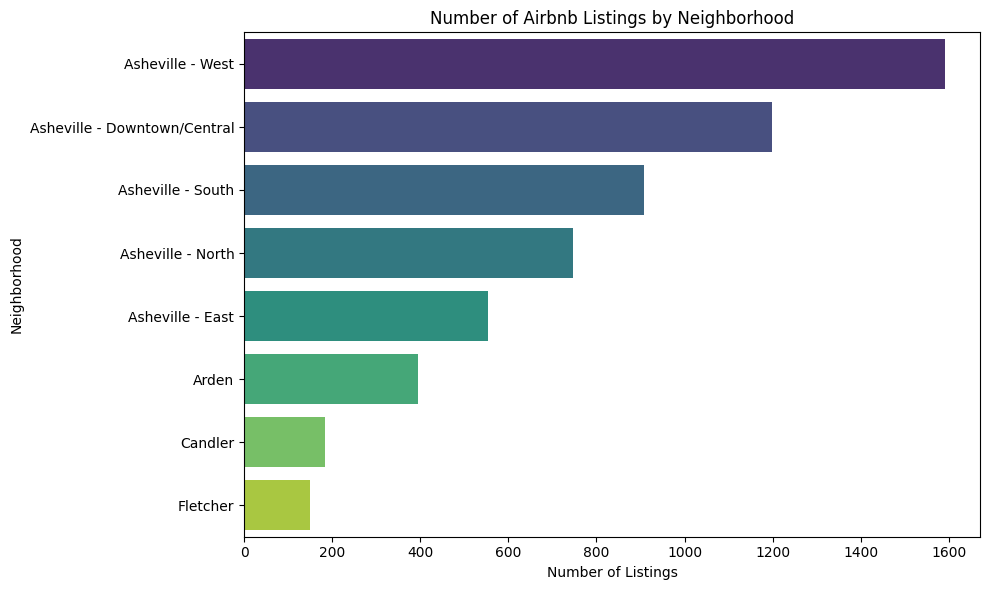

In [21]:
# creating a bar chart to show the number of listings per neighborhood
plot_df = listings_per_neighborhood.copy()
plot_df['neighborhood_name'] = plot_df['neighbourhood_cleansed'].map(zip_to_name)
plot_df = plot_df.sort_values('num_listings', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, y='neighborhood_name', x='num_listings', palette='viridis')
plt.title('Number of Airbnb Listings by Neighborhood')
plt.xlabel('Number of Listings')
plt.ylabel('Neighborhood')
plt.tight_layout()
plt.show()

C:\Users\reyes\AppData\Local\Temp\ipykernel_29520\737317944.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=price_df, y='neighborhood_name', x='avg_price', palette='coolwarm')


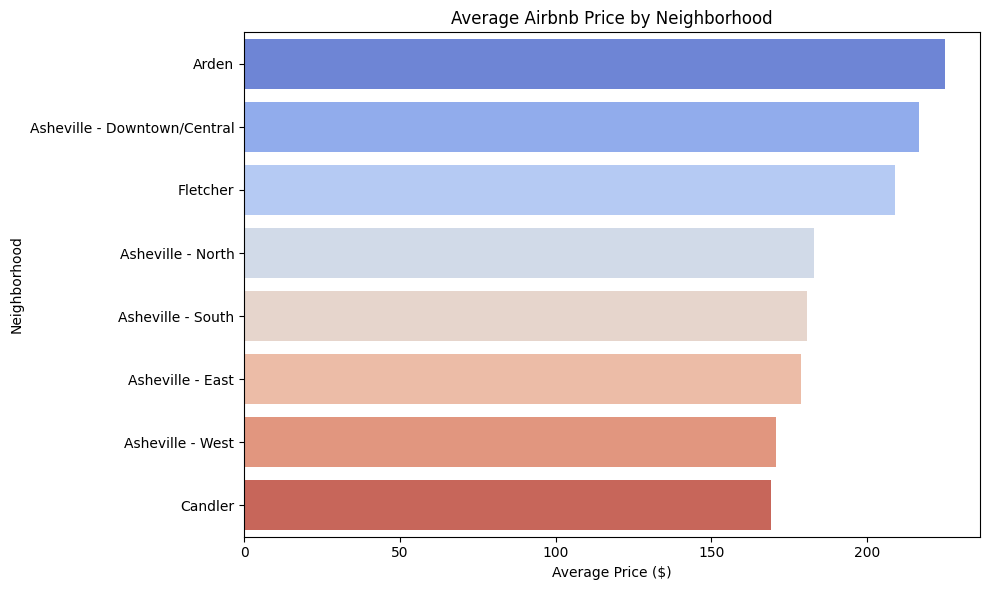

In [26]:
# creating a bar chart to show the average price per neighborhood
price_df = listings_per_neighborhood.copy()
price_df['neighborhood_name'] = price_df['neighbourhood_cleansed'].map(zip_to_name)
price_df = price_df.sort_values('avg_price', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=price_df, y='neighborhood_name', x='avg_price', palette='coolwarm')
plt.title('Average Airbnb Price by Neighborhood')
plt.xlabel('Average Price ($)')
plt.ylabel('Neighborhood')
plt.tight_layout()
plt.show()

C:\Users\reyes\AppData\Local\Temp\ipykernel_29520\3835705279.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\reyes\AppData\Local\Temp\ipykernel_29520\3835705279.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\reyes\AppData\Local\Temp\ipykernel_29520\3835705279.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\reyes\AppData\Local\Temp\ipykernel_29520\3835705279.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `h

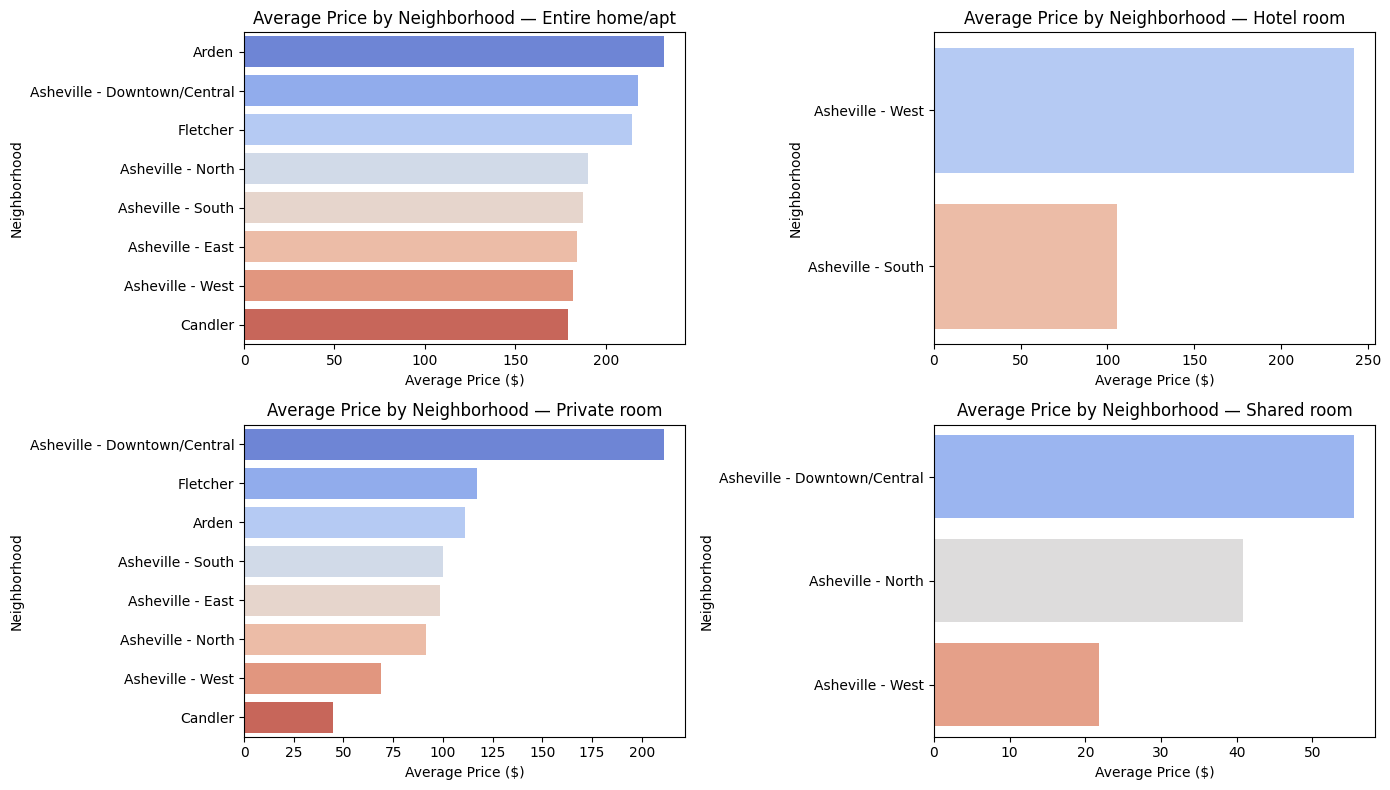

In [27]:
# creating separate bar charts to show average price per neighborhood for each room type
price_by_room = (
    listings
    .groupby(['neighbourhood_cleansed', 'room_type'])
    .agg(avg_price=('price', 'mean'))
    .reset_index()
)
price_by_room['neighborhood_name'] = price_by_room['neighbourhood_cleansed'].map(zip_to_name)
room_types = sorted(price_by_room['room_type'].unique())

n_rooms = len(room_types)
n_cols = 2
n_rows = (n_rooms + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4), sharex=False)
axes = axes.flatten()

for ax, room_type in zip(axes, room_types):
    room_df = price_by_room[price_by_room['room_type'] == room_type].sort_values('avg_price', ascending=False)
    sns.barplot(
        data=room_df,
        y='neighborhood_name',
        x='avg_price',
        palette='coolwarm',
        ax=ax
    )
    ax.set_title(f'Average Price by Neighborhood — {room_type}')
    ax.set_xlabel('Average Price ($)')
    ax.set_ylabel('Neighborhood')

for ax in axes[n_rooms:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

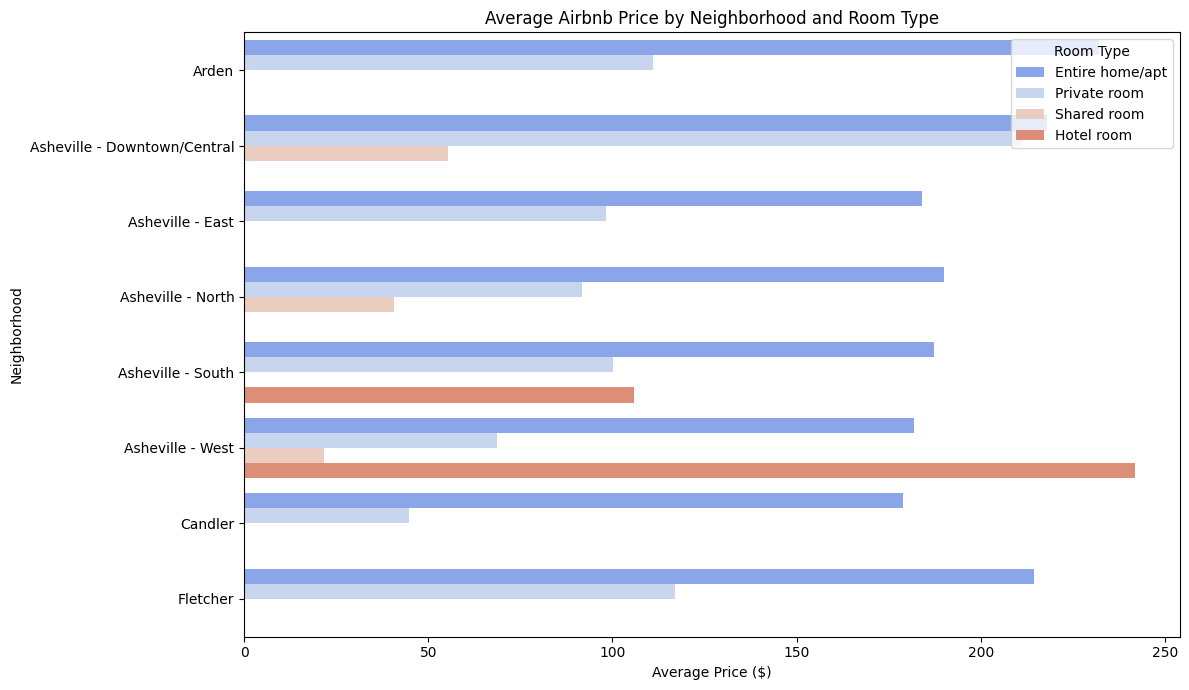

In [28]:
# creating a bar chart to show the average price per neighborhood and room type
price_by_room = (
    listings
    .groupby(['neighbourhood_cleansed', 'room_type'])
    .agg(avg_price=('price', 'mean'))
    .reset_index()
)
price_by_room['neighborhood_name'] = price_by_room['neighbourhood_cleansed'].map(zip_to_name)
price_by_room = price_by_room.sort_values(['neighborhood_name', 'room_type'])

plt.figure(figsize=(12, 7))
sns.barplot(
    data=price_by_room,
    y='neighborhood_name',
    x='avg_price',
    hue='room_type',
    palette='coolwarm'
)
plt.title('Average Airbnb Price by Neighborhood and Room Type')
plt.xlabel('Average Price ($)')
plt.ylabel('Neighborhood')
plt.legend(title='Room Type', loc='upper right')
plt.tight_layout()
plt.show()

## neighborhood overview
searching for common themes in neighborhood overviews


In [18]:
# do text analysis on neighborhood overview column to see if there are any common themes or keywords that could be used to create a new feature for the listings dataset
listings['neighborhood_overview']

0       We are within easy walk of pubs, breweries, mu...
1                                                     NaN
2       Our beautiful Grove Park Historic District clo...
3                                                     NaN
4       City vibes with country appeal. Peaceful neigh...
                              ...                        
5723    Aura sits in one of Asheville’s most coveted r...
5724                                                  NaN
5725    The beautiful historical Shiloh neighborhood b...
5726                                                  NaN
5727                                                  NaN
Name: neighborhood_overview, Length: 5728, dtype: str

# Market Demand
The guest's side of the market 

(ex: avg ocupancy rate, avg monthly reviews per listing)

Questions:
- Of the available nights, how many are actually booked?
- Are review counts (a proxy for bookings) going up or down over time?
- Which listings or neighborhoods are most sought after?
- Are there seasonal spikes in demand (e.g., fall foliage in Asheville)?



# Customer Comments 
(ex topics, sentiments)